In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings("ignore")


In [3]:
#import required libraries for clustering
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [4]:
df=pd.read_csv("onlineRetail.csv.zip",encoding = 'unicode_escape')

In [5]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [6]:
df.shape

(541909, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.dropna()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [11]:
df['CustomerID'] =df['CustomerID'].astype(str)

In [12]:
df['Amount'] =df['Quantity']*df['UnitPrice']
df_m =df.groupby('CustomerID')['Amount'].sum()
df_m = df_m.reset_index()
df_m.head()

,CustomerID,Amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [13]:
df_f =df.groupby('CustomerID')['InvoiceNo'].count()
df_f = df_f.reset_index()
df_f.columns = ['CustomerID','Frequency']
df_f.head()

,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [14]:
df_retail =pd.merge(df_m,df_f, on='CustomerID',how = 'inner')
df_retail.head()

,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17


In [15]:
df['InvoiceDate'] =pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [16]:
max_date = max(df['InvoiceDate'])
max_date

Timestamp('2011-12-09 12:50:00')

In [17]:
df['Diff'] =max_date - df['InvoiceDate']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,Diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00


In [18]:
df_p =df.groupby('CustomerID') ['Diff'].min()
df_p =df_p.reset_index()
df_p.head()

,CustomerID,Diff
0,12346.0,325 days 02:33:00
1,12347.0,1 days 20:58:00
2,12348.0,74 days 23:37:00
3,12349.0,18 days 02:59:00
4,12350.0,309 days 20:49:00


In [19]:
df_p['Diff'] = df_p['Diff'].dt.days
df_p.head()

,CustomerID,Diff
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [20]:
df_retail = pd.merge(df_retail,df_p,on='CustomerID',how ='inner')

df_retail.columns =['CustomerID','Amount','Frequency','Recency']
df_retail.head()

,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309


Text(0.5, 0, 'Attributes')

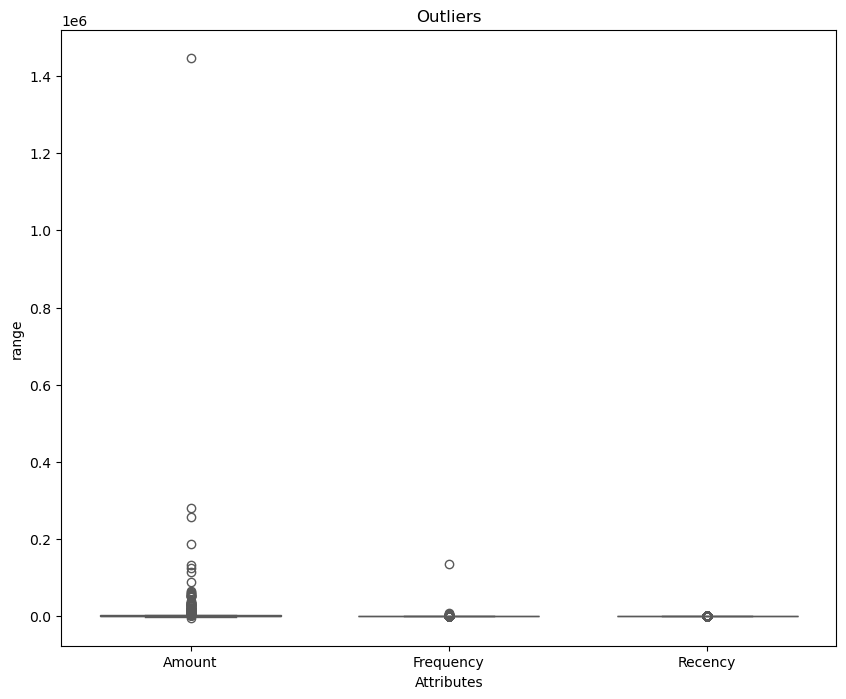

In [21]:
attributes =['Amount','Frequency','Recency']
plt.rcParams['figure.figsize'] = [10,8]
sns.boxplot(data = df_retail[attributes],orient ='v',palette ='Set2',whis=1.5,saturation=1,width =0.7)
plt.title("Outliers",)
plt.ylabel("range")
plt.xlabel("Attributes")

In [25]:
Q1=df_retail.Amount.quantile(0.05)
Q3=df_retail.Amount.quantile(0.95)
IQR=Q3  - Q1
df_retail = df_retail[(df_retail.Amount >= Q1 -1.5*IQR) & (df_retail.Amount <= Q3 + 1.5*IQR )]

In [26]:
Q1=df_retail.Recency.quantile(0.05)
Q3=df_retail.Recency.quantile(0.95)
IQR=Q3  - Q1
df_retail = df_retail[(df_retail.Recency >= Q1 -1.5*IQR) & (df_retail.Recency <= Q3 + 1.5*IQR )]

In [27]:
Q1=df_retail.Frequency.quantile(0.05)
Q3=df_retail.Frequency.quantile(0.95)
IQR=Q3  - Q1
df_retail = df_retail[(df_retail.Frequency >= Q1 -1.5*IQR) & (df_retail.Frequency <= Q3 + 1.5*IQR )]

In [28]:
df_retail.shape

(4294, 4)

In [29]:
df1 =  df_retail[['Amount','Frequency','Recency']]
scaler = StandardScaler()

In [30]:
df_retail_scaled =scaler.fit_transform(df1)
df_retail_scaled.shape

(4294, 3)

In [34]:
df_retail_scaled

array([[-0.72113889, -0.75308301,  2.30186785],
       [ 1.71972644,  1.04159382, -0.90626914],
       [ 0.29668496, -0.46394063, -0.18344815],
       ...,
       [-0.67536842, -0.70323088,  0.86612753],
       [-0.62112571, -0.64340832, -0.84685919],
       [ 0.31936065, -0.07509399, -0.50030119]], shape=(4294, 3))

In [35]:
df_retail_scaled =pd.DataFrame(df_retail_scaled)
df_retail_scaled.columns = ['Amount','Frequency','Recency']
df_retail_scaled.head()

,Amount,Frequency,Recency
0,-0.721139,-0.753083,2.301868
1,1.719726,1.041594,-0.906269
2,0.296685,-0.463941,-0.183448
3,0.274207,-0.045183,-0.737941
4,-0.531759,-0.603527,2.143441


In [46]:
ssd=[]
range_n_clusters=[2,3,4,5,6,7,8]
for num_clusters in range_n_clusters:
    Kmeans = KMeans(n_clusters=num_clusters,  max_iter=50)
    Kmeans.fit(df_retail_scaled)
    ssd.append(Kmeans.inertia_)

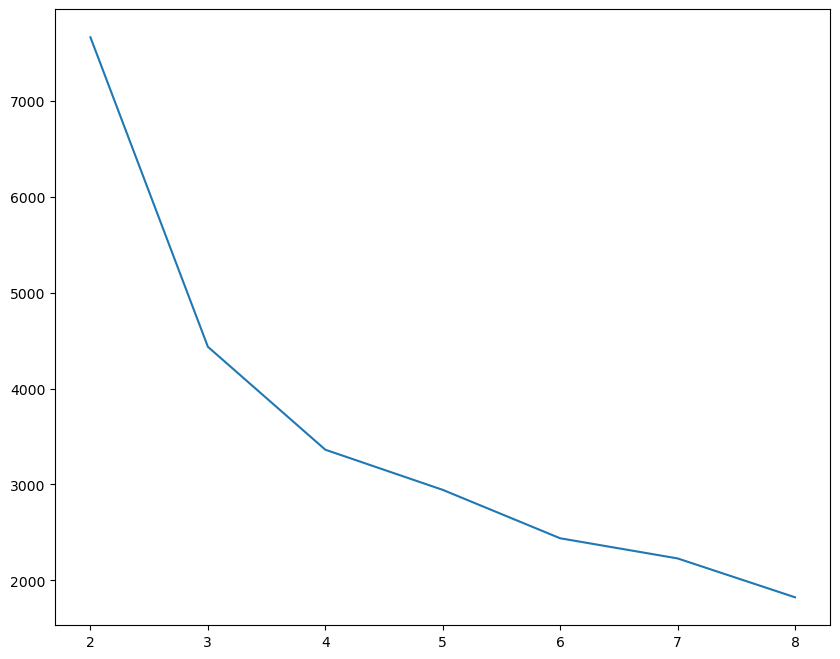

In [47]:
plt.plot(range_n_clusters,ssd)

In [49]:
Kmeans =KMeans (n_clusters =3,max_iter=50)
Kmeans.fit(df_retail_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,50
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [50]:
Kmeans.labels_

array([1, 2, 0, ..., 1, 0, 0], shape=(4294,), dtype=int32)

In [51]:
df_retail['cluster_Id'] = Kmeans.labels_
df_retail.head()

,CustomerID,Amount,Frequency,Recency,cluster_Id
0,12346.0,0.00,2,325,1
1,12347.0,4310.00,182,1,2
2,12348.0,1797.24,31,74,0
3,12349.0,1757.55,73,18,0
4,12350.0,334.40,17,309,1


In [54]:
df_retail['cluster_Id'].value_counts(ascending=True)

cluster_Id
2     499
1    1068
0    2727
Name: count, dtype: int64

In [58]:
X = df_retail.iloc[:, [1, 3]].values
X

array([[0.00000e+00, 3.25000e+02],
       [4.31000e+03, 1.00000e+00],
       [1.79724e+03, 7.40000e+01],
       ...,
       [8.08200e+01, 1.80000e+02],
       [1.76600e+02, 7.00000e+00],
       [1.83728e+03, 4.20000e+01]], shape=(4294, 2))

In [63]:
y_Kmeans=Kmeans.fit_predict(X)
[y_Kmeans==0,0]

[array([ True, False, False, ...,  True,  True, False], shape=(4294,)), 0]

<Axes: xlabel='Amount', ylabel='Recency'>

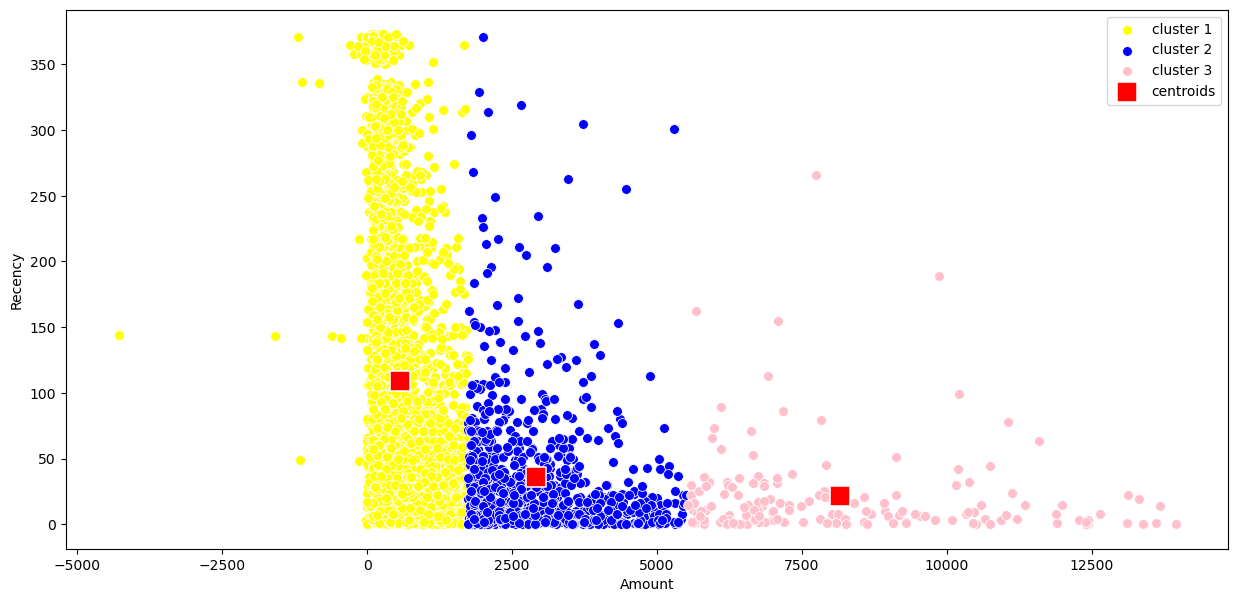

In [75]:
plt.figure(figsize=(15,7))
sns.scatterplot(x=X[y_Kmeans == 0, 0], y=X[y_Kmeans == 0, 1], color = 'yellow', label ='cluster 1', s=50)
sns.scatterplot(x=X[y_Kmeans == 1, 0], y=X[y_Kmeans == 1, 1], color = 'blue', label ='cluster 2', s=50)
sns.scatterplot(x=X[y_Kmeans == 2, 0], y=X[y_Kmeans == 2, 1], color = 'pink', label ='cluster 3', s=50)
plt.xlabel("Amount")
plt.ylabel("Recency")
sns.scatterplot(x=Kmeans.cluster_centers_[:4, 0], y=Kmeans.cluster_centers_[:4, 1],color = 'red', label = 'centroids',s=200,marker='s')
